# 03 · Descriptive & Diagnostic Analytics

**What happened, and why.** Built on top of the star schema from Phase 2
(`data/inventory_performance.db`) — this notebook computes:

1. A per-SKU×Warehouse **KPI snapshot**: Days of Supply, Inventory Turnover, observed Service Level, and an ABC (value) × XYZ (demand variability) classification computed from the actual simulated demand — not just read off the generator's own parameters.
2. **Excess / slow-moving / obsolete** flags, with the dollar value at risk.
3. A **monthly diagnostic decomposition** of inventory value by warehouse and ABC class — the table the "why did inventory change this month" AI Advisor query (Phase 7) will run on.

All logic lives in `src/kpi_engine.py` so Power BI, this notebook, and later phases share one implementation instead of three copies of the same formulas.

In [1]:
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = Path('/content/drive/MyDrive/inventory-intelligence-gsc')
except ImportError:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

import kpi_engine as kpi
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = PROJECT_ROOT / "data" / "inventory_performance.db"
OUT_DIR = PROJECT_ROOT / "data" / "processed" / "kpi_tables"

tables = kpi.build_all_kpi_tables(DB_PATH, OUT_DIR)
snapshot = tables["sku_warehouse_kpi_snapshot"]
monthly_diag = tables["monthly_inventory_diagnostic"]
print("Snapshot:", snapshot.shape, " | Monthly diagnostic:", monthly_diag.shape)

Snapshot: (2035, 21)  | Monthly diagnostic: (1224, 6)


## 1. Executive-level numbers (what Power BI page 1 will show)

In [2]:
total_inventory_value = (snapshot["on_hand_qty"] * snapshot["unit_cost"]).sum()
weighted_turnover = (snapshot["inventory_turnover"] * snapshot["on_hand_qty"] * snapshot["unit_cost"]).sum() / total_inventory_value
weighted_service_level = (snapshot["service_level"] * snapshot["on_hand_qty"] * snapshot["unit_cost"]).sum() / total_inventory_value
excess_value = snapshot["excess_value"].sum()

print(f"Total on-hand inventory value:  ${total_inventory_value:,.0f}")
print(f"Value-weighted turnover:        {weighted_turnover:.2f}x / year")
print(f"Value-weighted service level:   {weighted_service_level:.1%}")
print(f"Excess inventory value:         ${excess_value:,.0f}  ({excess_value/total_inventory_value:.1%} of total)")
print(f"SKUs flagged excess:            {snapshot['is_excess'].sum():,} / {len(snapshot):,}")
print(f"SKUs flagged slow-moving:       {snapshot['is_slow_moving'].sum():,}")
print(f"SKUs flagged obsolete:          {snapshot['is_obsolete'].sum():,}")

Total on-hand inventory value:  $4,010,211
Value-weighted turnover:        15.17x / year
Value-weighted service level:   99.3%
Excess inventory value:         $693,580  (17.3% of total)
SKUs flagged excess:            569 / 2,035
SKUs flagged slow-moving:       755
SKUs flagged obsolete:          7


## 2. ABC × XYZ matrix — the standard inventory-prioritization view

xyz_class,X,Y,Z
abc_class,,,
A,31,155,121
B,0,125,336
C,0,0,1267


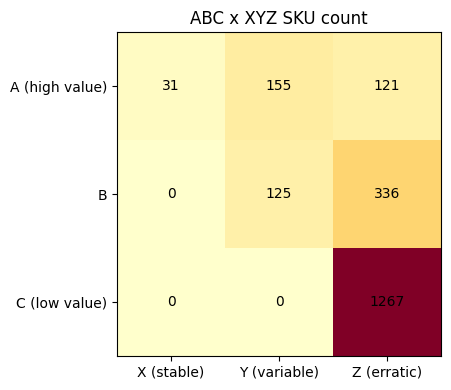

In [3]:
matrix = pd.crosstab(snapshot["abc_class"], snapshot["xyz_class"])
matrix = matrix.reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"], fill_value=0)
display(matrix)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matrix.values, cmap="YlOrRd")
ax.set_xticks(range(3)); ax.set_xticklabels(["X (stable)", "Y (variable)", "Z (erratic)"])
ax.set_yticks(range(3)); ax.set_yticklabels(["A (high value)", "B", "C (low value)"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, matrix.values[i, j], ha="center", va="center")
ax.set_title("ABC x XYZ SKU count")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "phase3_abc_xyz_matrix.png", dpi=130)
plt.show()

## 3. Excess inventory value by warehouse — where the money is stuck

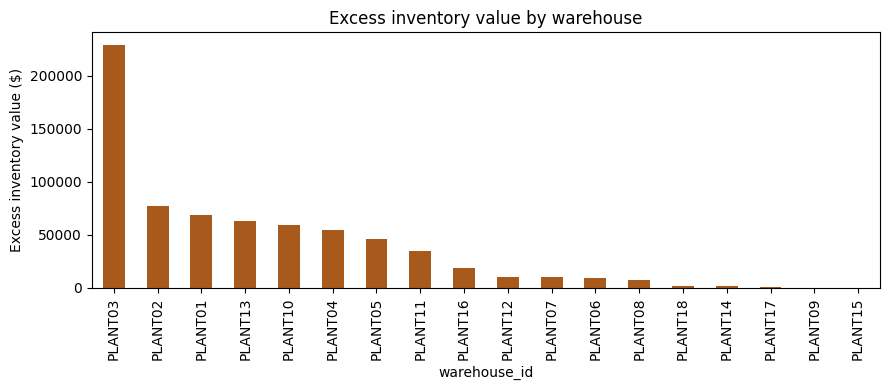

warehouse_id
PLANT03    229296.3594
PLANT02     77103.0864
PLANT01     68322.0559
PLANT13     63281.5113
PLANT10     59729.2669
Name: excess_value, dtype: float64

In [4]:
excess_by_wh = snapshot.groupby("warehouse_id")["excess_value"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
excess_by_wh.plot(kind="bar", ax=ax, color="#a85a1d")
ax.set_ylabel("Excess inventory value ($)")
ax.set_title("Excess inventory value by warehouse")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "phase3_excess_by_warehouse.png", dpi=130)
plt.show()
excess_by_wh.head(5)

## 4. Diagnostic: which warehouse/class drove last month's inventory-value change

In [5]:
latest_month = monthly_diag["month"].max()
last_month_moves = monthly_diag[monthly_diag["month"] == latest_month].dropna(subset=["delta"])
last_month_moves = last_month_moves.reindex(last_month_moves["delta"].abs().sort_values(ascending=False).index)
print(f"Largest inventory-value movers in {latest_month.date()}:")
last_month_moves[["warehouse_id", "abc_class", "delta"]].head(10)

Largest inventory-value movers in 2025-12-01:


,warehouse_id,abc_class,delta
1212,PLANT14,A,-1772.094935
1222,PLANT18,B,-1667.684266
1191,PLANT07,A,-1437.145917
1198,PLANT09,B,-1214.355290
1195,PLANT08,B,-1115.489224
1219,PLANT17,B,876.393022
1197,PLANT09,A,827.656720
1209,PLANT13,A,-784.531935
1218,PLANT17,A,659.105720
1182,PLANT04,A,498.072334


## 5. Saved outputs

`data/processed/kpi_tables/sku_warehouse_kpi_snapshot.parquet` and
`monthly_inventory_diagnostic.parquet` — both are what Power BI connects to
in Phase 6, and what the AI Advisor's tool functions query in Phase 7.
Next: `04_forecasting.ipynb` (Phase 4 — predictive analytics).